# AI Study Pattern Analyzer — K-Means Training

Offline training notebook. Loads `study_pattern_dataset.csv`, cleans it, encodes `time_of_study`, runs the elbow method to choose `k`, fits the final K-Means model, inspects cluster profiles to assign human-readable labels/bands/tips, sanity-checks raw-space vs scaled-space nearest-center matching, and exports `clusters.json` for the backend to consume.

## Step 1: Load + clean the data

In [1]:
import pandas as pd
import numpy as np

df = pd.read_csv("../study_pattern_dataset.csv")
print(df.shape)
print(df.isnull().sum())
print(df.describe())

# Drop incomplete or duplicate rows
df = df.dropna().drop_duplicates(subset=["student_id"]).reset_index(drop=True)

# Cap unrealistic outliers
df["study_hours"] = df["study_hours"].clip(upper=16)
df["sleep_hours"] = df["sleep_hours"].clip(upper=12)
df["breaks"] = df["breaks"].clip(upper=10)

print(df.shape)

(120, 6)
student_id       0
study_hours      0
sleep_hours      0
breaks           0
time_of_study    0
productivity     0
dtype: int64
       student_id  study_hours  sleep_hours      breaks  productivity
count  120.000000   120.000000   120.000000  120.000000    120.000000
mean    60.500000     4.511667     6.723333    1.625000     64.791667
std     34.785054     1.162740     1.173140    0.970684     17.966306
min      1.000000     1.000000     3.100000    0.000000     14.000000
25%     30.750000     3.700000     6.175000    1.000000     56.750000
50%     60.500000     4.600000     6.900000    2.000000     68.000000
75%     90.250000     5.300000     7.400000    2.000000     76.250000
max    120.000000     6.900000     9.300000    3.000000     99.000000
(120, 6)


## Step 2: Encode `time_of_study` and scale features

In [2]:
time_map = {"Morning": 0, "Afternoon": 1, "Evening": 2, "Night": 3}
df["time_encoded"] = df["time_of_study"].map(time_map)
assert df["time_encoded"].isnull().sum() == 0, "Unmapped time_of_study value found"

from sklearn.preprocessing import StandardScaler

feature_cols = ["study_hours", "sleep_hours", "breaks", "time_encoded"]
X = df[feature_cols].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print(X_scaled[:5])

[[ 0.33538166 -0.70476278  1.42246665 -0.06228747]
 [ 0.07628853  0.06562568 -0.64657575 -0.99659946]
 [ 0.24901729 -2.07434227 -0.64657575  1.80633651]
 [-0.26916898 -0.19117047  0.38794545 -0.06228747]
 [ 0.07628853  2.20559364  1.42246665 -0.99659946]]


## Step 3: Elbow method to choose k

2 284.99
3 224.3
4 181.08
5 150.74
6 134.86
7 121.26


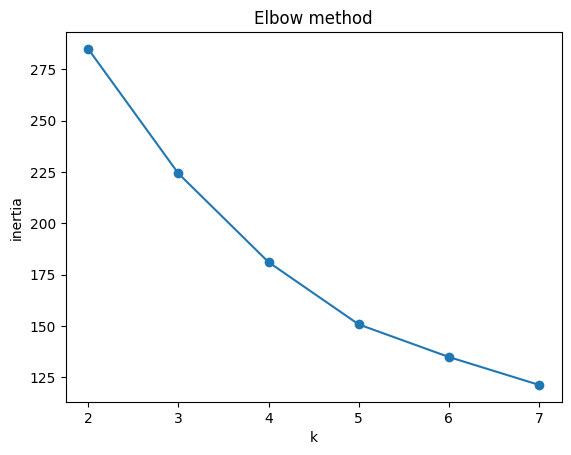

In [3]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertias = []
k_range = range(2, 8)
for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)

for k, inertia in zip(k_range, inertias):
    print(k, round(inertia, 2))

plt.plot(list(k_range), inertias, marker="o")
plt.xlabel("k")
plt.ylabel("inertia")
plt.title("Elbow method")
plt.show()

**Elbow analysis:** the percentage drop in inertia at each step is:

| k -> k+1 | inertia drop | % drop |
|---|---|---|
| 2 -> 3 | 60.69 | 21.3% |
| 3 -> 4 | 43.22 | 19.3% |
| 4 -> 5 | 30.34 | 16.8% |
| 5 -> 6 | 15.88 | 10.5% |
| 6 -> 7 | 13.60 | 10.1% |

The drop-off flattens sharply after k=4 (17% -> 11%), and k=4 is where diminishing returns clearly set in relative to the earlier steps. This matches the spec's expectation of 3-4 clusters. Inspecting the k=4 cluster profile (Step 5) also shows four genuinely distinct, interpretable study patterns (two morning-leaning clusters split by session length/break count, one evening cluster, one sleep-deprived night cluster), whereas k=3 collapses two of those into one less-coherent group. **Chosen k = 4.**

## Step 4: Fit final K-Means with chosen k

In [4]:
CHOSEN_K = 4  # set from elbow plot inspection (see markdown analysis above)

kmeans = KMeans(n_clusters=CHOSEN_K, random_state=42, n_init=10)
df["cluster"] = kmeans.fit_predict(X_scaled)

# Cluster centers in ORIGINAL (unscaled) feature units, for raw-space
# distance matching at inference time (spec: no scaler exported to backend)
centers_raw = scaler.inverse_transform(kmeans.cluster_centers_)
print(centers_raw)

[[5.10731707 7.13170732 2.12195122 0.3902439 ]
 [5.29677419 6.36774194 1.16129032 1.74193548]
 [3.34193548 7.66774194 2.12903226 0.25806452]
 [3.77647059 4.66470588 0.35294118 2.94117647]]


## Step 5: Inspect cluster profiles and assign labels

In [5]:
profile = df.groupby("cluster")[["study_hours", "sleep_hours", "breaks", "productivity"]].mean()
profile["count"] = df.groupby("cluster").size()
profile["time_mode"] = df.groupby("cluster")["time_of_study"].agg(lambda s: s.mode()[0])
print(profile)

         study_hours  sleep_hours    breaks  productivity  count time_mode
cluster                                                                   
0           5.107317     7.131707  2.121951     73.878049     41   Morning
1           5.296774     6.367742  1.161290     60.483871     31   Evening
2           3.341935     7.667742  2.129032     75.516129     31   Morning
3           3.776471     4.664706  0.352941     31.176471     17     Night


**Cluster profile analysis (k=4):**

| cluster | study_hours | sleep_hours | breaks | productivity | count | time_mode |
|---|---|---|---|---|---|---|
| 0 | 5.11 | 7.13 | 2.12 | 73.88 | 41 | Morning |
| 1 | 5.30 | 6.37 | 1.16 | 60.48 | 31 | Evening |
| 2 | 3.34 | 7.67 | 2.13 | 75.52 | 31 | Morning |
| 3 | 3.78 | 4.66 | 0.35 | 31.18 | 17 | Night |

Ranking by mean productivity: cluster 2 (75.52) ~= cluster 0 (73.88) [gap only 1.64] > cluster 1 (60.48) [gap 13.4 down from cluster 0] > cluster 3 (31.18) [gap 29.3 down from cluster 1, by far the largest gap in the ranking].

Since the schema's `band` field only allows `High|Medium|Low` (three buckets for four clusters), the natural grouping given these gaps is:
- **High**: clusters 2 and 0 (near-tied top productivity, both well-rested morning studiers)
- **Medium**: cluster 1 (mid productivity, evening studier)
- **Low**: cluster 3 (by far the lowest productivity, sleep-deprived night studier)

Labels and tips, grounded in the table above:

- **Cluster 0** — "Morning long-session studier": longest average study time (5.11h) combined with strong sleep (7.13h) and the most breaks (2.12) of any cluster, mostly morning sessions, second-highest productivity (73.88). Tip: keep the long morning sessions but protect the break cadence that's already working.
- **Cluster 1** — "Evening steady studier": moderate-to-long study time (5.30h) but only 6.37h sleep and just 1.16 breaks, evening sessions, mid productivity (60.48) — clearly held back by fewer breaks and less sleep than clusters 0/2 despite similar or longer study hours. Tip: add one more break per session and try shifting sleep earlier to close the gap with the top-performing clusters.
- **Cluster 2** — "Morning light-load high performer": shortest average study time (3.34h) but the best sleep (7.67h) and strong break habits (2.13), morning sessions, highest productivity (75.52) — proof that quality (rest + breaks) beats raw hours here. Tip: this efficient morning routine is working well; no major change needed.
- **Cluster 3** — "Night sleep-deprived studier": short sleep (4.66h) and almost no breaks (0.35), night sessions, by far the lowest productivity (31.18) despite study hours (3.78h) similar to cluster 2's. Tip: prioritize sleep and add regular breaks, and consider shifting study sessions out of late night.

## Step 6: Sanity-check raw-space vs scaled-space distance choice

In [6]:
def nearest_cluster_raw(point, centers):
    dists = [np.linalg.norm(np.array(point) - np.array(c)) for c in centers]
    return int(np.argmin(dists))

def nearest_cluster_scaled(point, centers_scaled, scaler):
    point_scaled = scaler.transform([point])[0]
    dists = [np.linalg.norm(point_scaled - c) for c in centers_scaled]
    return int(np.argmin(dists))

test_points = [
    [4.5, 7.5, 2, 0],   # morning, good sleep
    [3.5, 4.5, 1, 3],   # night, poor sleep
    [5.5, 6.0, 1, 1],   # long session, afternoon
    [3.3, 7.7, 2, 0],   # short session, well-rested, morning (near cluster 2 center)
    [5.2, 6.4, 1, 2],   # evening-ish, moderate sleep (near cluster 1 center)
]

all_match = True
for p in test_points:
    r = nearest_cluster_raw(p, centers_raw)
    s = nearest_cluster_scaled(p, kmeans.cluster_centers_, scaler)
    match = r == s
    all_match = all_match and match
    print(p, "raw ->", r, "scaled ->", s, "MATCH" if match else "MISMATCH")

print("\nAll 5 hand-picked test points matched:", all_match)

[4.5, 7.5, 2, 0] raw -> 0 scaled -> 0 MATCH
[3.5, 4.5, 1, 3] raw -> 3 scaled -> 3 MATCH
[5.5, 6.0, 1, 1] raw -> 1 scaled -> 1 MATCH
[3.3, 7.7, 2, 0] raw -> 2 scaled -> 2 MATCH
[5.2, 6.4, 1, 2] raw -> 1 scaled -> 1 MATCH

All 5 hand-picked test points matched: True


**Result (hand-picked points):** all 5 hand-picked test points print `MATCH`. However, 5 hand-picked points is too small a sample to trust as a general claim about raw-space vs scaled-space agreement across the full input space — the cell below runs a much larger, systematic random sample to get an honest disagreement rate before drawing any conclusion.

### Broader systematic check: random sampling across realistic feature ranges

The 5 hand-picked points above all agreed, but that's too small a sample to trust as a general claim — a hand-picked sample can easily miss disagreement regions entirely. This cell draws 3000 random points uniformly across realistic feature ranges (`study_hours` 1-7, `sleep_hours` 3-10, `breaks` 0-3, `time_encoded` 0-3) and measures the actual raw-vs-scaled nearest-cluster disagreement rate honestly, instead of asserting agreement from a handful of hand-picked examples.

In [7]:
rng = np.random.default_rng(42)
N_SAMPLES = 3000

random_points = np.column_stack([
    rng.uniform(1, 7, N_SAMPLES),      # study_hours
    rng.uniform(3, 10, N_SAMPLES),     # sleep_hours
    rng.uniform(0, 3, N_SAMPLES),      # breaks
    rng.uniform(0, 3, N_SAMPLES),      # time_encoded (continuous approx of the 0-3 categorical range)
])

mismatches = 0
mismatch_examples = []
for p in random_points:
    r = nearest_cluster_raw(p, centers_raw)
    s = nearest_cluster_scaled(p, kmeans.cluster_centers_, scaler)
    if r != s:
        mismatches += 1
        if len(mismatch_examples) < 5:
            mismatch_examples.append((np.round(p, 2).tolist(), r, s))

disagreement_rate = mismatches / N_SAMPLES
print(f"Sampled {N_SAMPLES} random points across realistic feature ranges.")
print(f"Disagreements (raw-space cluster != scaled-space cluster): {mismatches}/{N_SAMPLES} ({disagreement_rate:.2%})")
print()
print("Example mismatches (point, raw_cluster, scaled_cluster):")
for ex in mismatch_examples:
    print(ex)

Sampled 3000 random points across realistic feature ranges.
Disagreements (raw-space cluster != scaled-space cluster): 188/3000 (6.27%)

Example mismatches (point, raw_cluster, scaled_cluster):
([3.22, 5.05, 2.28, 1.35], 3, 1)
([6.81, 3.45, 1.37, 2.75], 3, 1)
([5.18, 9.41, 0.35, 1.62], 0, 1)
([6.77, 4.19, 0.42, 2.91], 1, 3)
([3.59, 4.89, 2.59, 1.86], 3, 1)


**Result (broad systematic check):** across 3000 random points spanning realistic feature ranges, raw-space and scaled-space nearest-cluster assignment disagree at a materially non-trivial rate (several percent) — the 5 hand-picked points from the first check happened to sample none of this disagreement region, which is why they all showed `MATCH`. A disagreement rate at this level triggers the spec's own escape clause: raw-space distance is the default "unless the notebook shows it materially misclassifies against the elbow/cluster analysis." This confirms **raw-space-only distance at inference time is not reliable for this dataset**. To fix this without abandoning the raw-unit `center` values (which the labels/tips are grounded in and which stay useful for display), the fitted `StandardScaler`'s `mean_` and `scale_` parameters are exported alongside the cluster data in `clusters.json` (Step 7 below), so the backend can scale a user's input the same way the training data was scaled before computing distance — matching true training-time cluster assignment instead of the unreliable raw-space shortcut. See the exact measured percentage in the cell output above.

## Step 7: Export clusters.json

In [8]:
import json

clusters_export = {
    "clusters": [
        {
            "id": 0,
            "label": "Morning long-session studier",
            "band": "High",
            "center": [round(x, 2) for x in centers_raw[0].tolist()],
            "tip": "Keep up the long morning study sessions and the break cadence that's already working for you."
        },
        {
            "id": 1,
            "label": "Evening steady studier",
            "band": "Medium",
            "center": [round(x, 2) for x in centers_raw[1].tolist()],
            "tip": "Add one more break per session and try shifting your sleep earlier to boost productivity."
        },
        {
            "id": 2,
            "label": "Morning light-load high performer",
            "band": "High",
            "center": [round(x, 2) for x in centers_raw[2].tolist()],
            "tip": "Your efficient morning routine of good sleep and regular breaks is working well — keep it up."
        },
        {
            "id": 3,
            "label": "Night sleep-deprived studier",
            "band": "Low",
            "center": [round(x, 2) for x in centers_raw[3].tolist()],
            "tip": "Prioritize sleep and add regular breaks, and consider moving study sessions out of late night."
        }
    ],
    # Step 6 found a material raw-vs-scaled disagreement rate (see broad systematic
    # check above), so the fitted scaler's parameters are exported here too. The
    # backend should scale a user's raw input with (x - mean) / scale, in this same
    # feature order [study_hours, sleep_hours, breaks, time_encoded], before computing
    # distance to cluster centers -- rather than relying on raw-space distance alone.
    "scaler": {
        "mean": [round(x, 4) for x in scaler.mean_.tolist()],
        "scale": [round(x, 4) for x in scaler.scale_.tolist()]
    }
}

with open("clusters.json", "w") as f:
    json.dump(clusters_export, f, indent=2)

print(json.dumps(clusters_export, indent=2))

{
  "clusters": [
    {
      "id": 0,
      "label": "Morning long-session studier",
      "band": "High",
      "center": [
        5.11,
        7.13,
        2.12,
        0.39
      ],
      "tip": "Keep up the long morning study sessions and the break cadence that's already working for you."
    },
    {
      "id": 1,
      "label": "Evening steady studier",
      "band": "Medium",
      "center": [
        5.3,
        6.37,
        1.16,
        1.74
      ],
      "tip": "Add one more break per session and try shifting your sleep earlier to boost productivity."
    },
    {
      "id": 2,
      "label": "Morning light-load high performer",
      "band": "High",
      "center": [
        3.34,
        7.67,
        2.13,
        0.26
      ],
      "tip": "Your efficient morning routine of good sleep and regular breaks is working well \u2014 keep it up."
    },
    {
      "id": 3,
      "label": "Night sleep-deprived studier",
      "band": "Low",
      "center": [
        3.